In [12]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# Windows 한글 폰트 우선순위
preferred_fonts = ['Malgun Gothic', 'AppleGothic', 'NanumGothic']

available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = None

for font_name in preferred_fonts:
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font is None:
    raise ValueError("사용 가능한 한글 폰트를 찾지 못했습니다. Malgun Gothic 또는 NanumGothic 설치 여부를 확인하세요.")

plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', font=selected_font)

print(f"적용된 폰트: {selected_font}")


base_path = Path.cwd()
file_path = next(base_path.rglob("final_merged_user(단칼)_v3.xlsx"))

df_final_merged_user_v3 = pd.read_excel(file_path, sheet_name="Sheet1")

# print(file_path)
# print(df_final_merged_user_v3.shape)
# display(df_final_merged_user_v3.head())


적용된 폰트: Malgun Gothic


> 요금제 더미 변수 분포 확인

`is_basic`, `is_standard`, `is_premium`은 `concurrent_streams` 값을 바탕으로 만든 원핫인코딩 파생변수입니다.  
이 EDA는 각 요금제에 해당하는 유저 수가 얼마나 되는지 확인하여, 표본이 어떤 요금제에 많이 분포하는지 파악하기 위한 분석입니다.

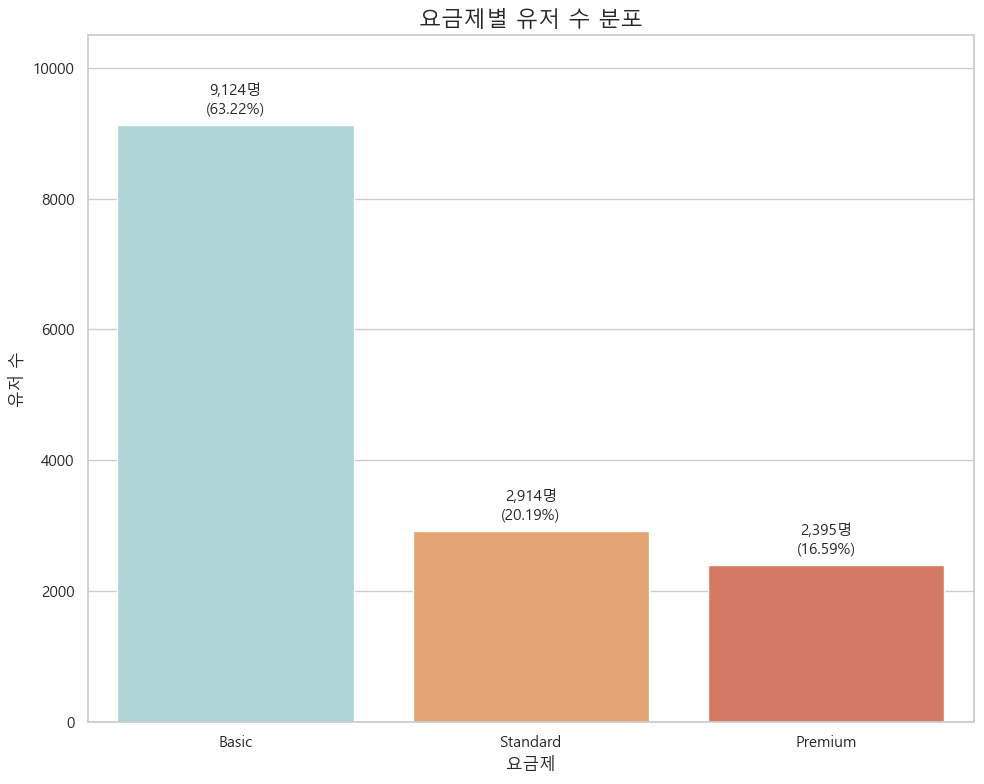

In [13]:
plan_counts = df_final_merged_user_v3[['is_basic', 'is_standard', 'is_premium']].sum().astype(int)
plan_ratios = (plan_counts / len(df_final_merged_user_v3) * 100).round(2)

plan_plot_df = pd.DataFrame({
    'plan': ['Basic', 'Standard', 'Premium'],
    'count': [
        plan_counts['is_basic'],
        plan_counts['is_standard'],
        plan_counts['is_premium']
    ],
    'ratio': [
        plan_ratios['is_basic'],
        plan_ratios['is_standard'],
        plan_ratios['is_premium']
    ]
})

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=plan_plot_df,
    x='plan',
    y='count',
    hue='plan',
    palette=['#A8DADC', '#F4A261', '#E76F51'],
    legend=False
)

for i, row in plan_plot_df.iterrows():
    ax.text(
        i,
        row['count'] + 120,
        f"{row['count']:,}명\n({row['ratio']}%)",
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('요금제별 유저 수 분포', fontsize=16)
plt.xlabel('요금제', fontsize=12)
plt.ylabel('유저 수', fontsize=12)
plt.ylim(0, plan_plot_df['count'].max() * 1.15)
plt.tight_layout()
plt.show()


> 프로모션 가격 유저 세그먼트 확인

`is_100won_deal`은 첫 결제를 100원에 시작한 유저 여부를, `is_half_priced`는 정가 7,900원, 10,900원, 13,900원의 정확한 절반인 3,950원, 5,450원, 6,950원으로 결제한 유저 여부를 나타내는 파생변수입니다.  
이 EDA는 프로모션 가격으로 구독 중인 유저가 전체에서 얼마나 큰 비중을 차지하는지 확인하기 위한 분석입니다. 가격 혜택을 유지하고 있는 집단은 가격 민감도가 높고, retention 관점에서 따로 볼 필요가 있는 세그먼트일 수 있습니다.

,segment,count,ratio
0,100원 딜,7517,52.08
1,Half Price,182,1.26
2,정가/기타,6734,46.66


프로모션 가격 사용자 합계: 7,699명 (53.34%)


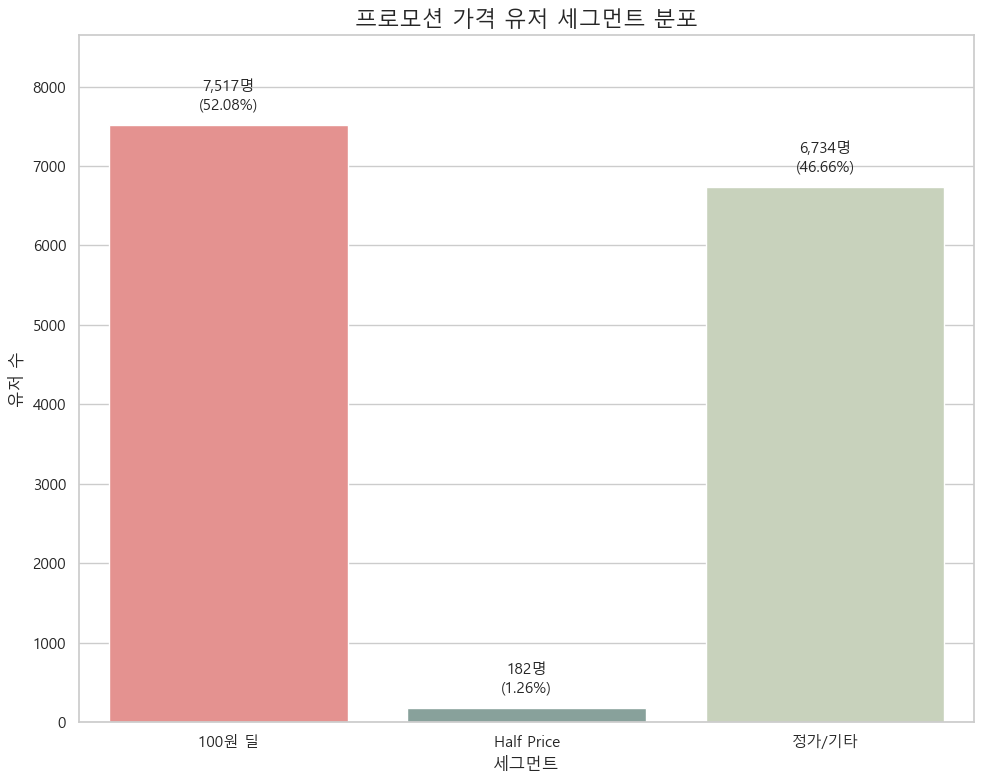

In [15]:
promo_counts = pd.Series({
    '100원 딜': int(df_final_merged_user_v3['is_100won_deal'].sum()),
    'Half Price': int(df_final_merged_user_v3['is_half_priced'].sum())
})

promo_counts['정가/기타'] = len(df_final_merged_user_v3) - promo_counts.sum()
promo_ratios = (promo_counts / len(df_final_merged_user_v3) * 100).round(2)

promo_plot_df = pd.DataFrame({
    'segment': promo_counts.index,
    'count': promo_counts.values,
    'ratio': promo_ratios.values
})

total_promo_count = int(df_final_merged_user_v3['is_100won_deal'].sum() + df_final_merged_user_v3['is_half_priced'].sum())
total_promo_ratio = round(total_promo_count / len(df_final_merged_user_v3) * 100, 2)

display(promo_plot_df)
print(f"프로모션 가격 사용자 합계: {total_promo_count:,}명 ({total_promo_ratio}%)")

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=promo_plot_df,
    x='segment',
    y='count',
    hue='segment',
    palette=['#F28482', '#84A59D', '#C8D5B9'],
    legend=False
)

for i, row in promo_plot_df.iterrows():
    ax.text(
        i,
        row['count'] + len(df_final_merged_user_v3) * 0.01,
        f"{int(row['count']):,}명\n({row['ratio']}%)",
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('프로모션 가격 유저 세그먼트 분포', fontsize=16)
plt.xlabel('세그먼트', fontsize=12)
plt.ylabel('유저 수', fontsize=12)
plt.ylim(0, promo_plot_df['count'].max() * 1.15)
plt.tight_layout()
plt.show()


> 재구독 여부 분포 확인

`repurchase`는 유저가 구독을 해지한 뒤 재구독했는지 여부를 나타내는 변수입니다.  
이 EDA는 전체 유저 중 재구독 경험이 있는 유저(1)와 없는 유저(0)의 비율을 파악하기 위한 분석입니다.

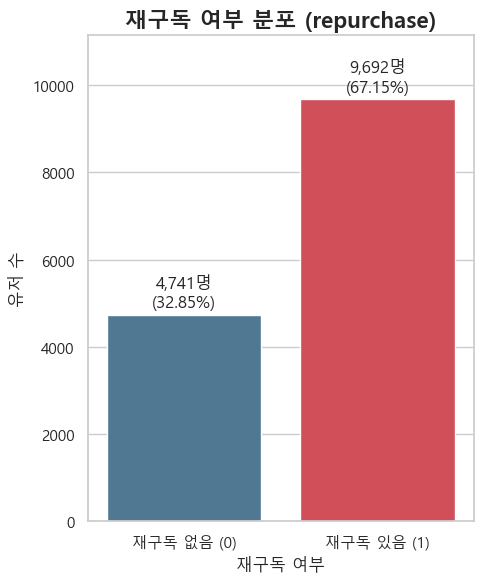

In [27]:
repurchase_counts = df_final_merged_user_v3['repurchase'].value_counts().sort_index()
repurchase_ratios = (repurchase_counts / len(df_final_merged_user_v3) * 100).round(2)

repurchase_plot_df = pd.DataFrame({
    'label': ['재구독 없음 (0)', '재구독 있음 (1)'],
    'count': repurchase_counts.values,
    'ratio': repurchase_ratios.values
})

plt.figure(figsize=(5, 6))
ax = sns.barplot(
    data=repurchase_plot_df,
    x='label',
    y='count',
    hue='label',
    palette=['#457B9D', '#E63946'],
    legend=False
)

for i, row in repurchase_plot_df.iterrows():
    ax.text(
        i,
        row['count'] + len(df_final_merged_user_v3) * 0.005,
        f"{int(row['count']):,}명\n({row['ratio']}%)",
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.title('재구독 여부 분포 (repurchase)', fontsize=16, fontweight='bold')
plt.xlabel('재구독 여부', fontsize=12)
plt.ylabel('유저 수', fontsize=12)
plt.ylim(0, repurchase_plot_df['count'].max() * 1.15)
plt.tight_layout()
plt.show()